# Sentiment Analysis of Game Reviews

The Clean Steam Review dataset from SirSkandrani is a collection of Steam user-reviewed data that can be used for text classification, opinion mining and sentiment analysis purposes. The dataset is aimed at being used via the Natural Language Processing domain. (Adem, 2016)

**Objective**<br>
This project aims to create a machine learning model that can determine whether a Steam user's review of a game is positive or negative based on the Review Text provided. The aim is to use the review text as input and sentiment as output to build a supervised sentiment classification model.


## Task -1:

In [ ]:
# install all the required libraries
%pip install datasets pandas matplotlib seaborn -q

%pip install wordcloud -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "datasets", "pandas", "matplotlib", "seaborn", "-q"])

# preliminary libraries
import pandas as pd
from datasets import load_dataset

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import textwrap


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# load the dataset from Hugging face

st_rev = load_dataset("SirSkandrani/steam_reviews_clean")
print("Dataset loaded successfully")

Dataset loaded successfully


### **Exploring the dataset**

In [ ]:
# understand the dataset
print("Dataset information: ")

# dataset structure
print(st_rev)

Dataset information: 
DatasetDict({
    train: Dataset({
        features: ['text', 'label', '__index_level_0__'],
        num_rows: 4476233
    })
})


This result shows the available splits in the dataset

In [ ]:
# convert the train split to a pandas dataframe for better analysis
train_df = st_rev['train'].to_pandas()

# shape of the dataset
print("Shape of the dataset: \n", train_df.shape)

# available columns
print("\nColumns: \n", train_df.columns)

# inspect the first few rows of the dataset
print("\nFirst 5 rows of the dataset: ")
print(train_df.head())

# null values per column
print("\nNull values per column: ")
print(train_df.isnull().sum())

Shape of the dataset: 
 (4476233, 3)

Columns: 
 Index(['text', 'label', '__index_level_0__'], dtype='object')

First 5 rows of the dataset: 
                                                text  label  __index_level_0__
0                                     ruined my life      1                  0
1  this will be more of a my experience with this...      1                  1
2                       this game saved my virginity      1                  2
3  • do you like original games • do you like gam...      1                  3
4             easy to learn hard to master                1                  4

Null values per column: 
text                 0
label                0
__index_level_0__    0
dtype: int64


From the above execution we got the basic information of the dataset and the it contains 0 NULL values

In [ ]:
# keeping only required features
train_df = train_df[['text', 'label']]

train_df.head()

,text,label
0,ruined my life,1
1,this will be more of a my experience with this...,1
2,this game saved my virginity,1
3,• do you like original games • do you like gam...,1
4,easy to learn hard to master,1


In [ ]:
# columns' datatypes
print("\n Columns datatypes: \n", train_df.dtypes)


 Columns datatypes: 
 text     object
label     int64
dtype: object


In [ ]:
# statistical summary of the dataset
print("\n Statistical summary: \n", train_df.describe().round(2))


 Statistical summary: 
             label
count  4476233.00
mean         0.63
std          0.78
min         -1.00
25%          1.00
50%          1.00
75%          1.00
max          1.00


### **Understand the Review text & Recommendation features**

In [ ]:
# 1. Review field analysis - Max review length

train_df['review_length'] = train_df['text'].dropna().apply(lambda x: len(x.split()))
print("\n Max review length by word count statistics")


print("Maximum review length: ", train_df['review_length'].max())


 Max review length by word count statistics
Maximum review length:  3959


The maximum length of the review text was analysed to determine appropriate tokenisation settings.

In [ ]:
# 2. Recommendation field analysis (label column)

# unique values in the sentiment column
print("\n Unique values in the sentiment column: \n", train_df['label'].value_counts())


 Unique values in the sentiment column: 
 label
 1    3650100
-1     826133
Name: count, dtype: int64


It is clear from the above result that the dataset provides a pre-defined label column, eliminating the need to manually map the recommendation field.

### **Mapping strategy**

In the original steam review dataset, users provide two inputs: review text and recommendations indicating whether they recommend the game or not.
- Recommended - positive review
- Not recommended - negative review

The cleaned version of this dataset used in this project provides a 'label' column.

Labels are encoded as m
- 1 - Positive sentiment
- -1 - Negative sentiment

Though the sentiment labels were mapped, they are not compatible with standard ML models.

In [ ]:
# update the column names
train_df = train_df.rename(columns={'text': 'review', 'label': 'sentiment'})

For better readability and quality the column names were renamed.

In [ ]:
# converting the sentiment labels to binary (0 and 1)
train_df['sentiment'] = train_df['sentiment'].replace({-1: 0, 1: 1})

train_df['sentiment'].value_counts()

sentiment
1    3650100
0     826133
Name: count, dtype: int64

**Reasons for converting to standard label format: <br>**
- Most ML/ transformer models expect labels starting from 0, 1, 2, ...
- Hugging Face's AutoModelForSequenceClassification, which expects non-negative integer class indices.
- Having -1 label causes indexing error, incorrect loss calculation during training <br>
<br>

| Original sentiment | After converting |
| ----------| ------- |
| Positive(1) | 1 |
| Negative(-1) | 0 |

**This transformation ensures that the recommendation labels follow standard formats like 0, 1, 2,...**

In [ ]:
# Final preview of the dataset
print("\n Final preview of the dataset: ")
print(train_df.head())


 Final preview of the dataset: 
                                              review  sentiment  review_length
0                                     ruined my life          1              3
1  this will be more of a my experience with this...          1            446
2                       this game saved my virginity          1              5
3  • do you like original games • do you like gam...          1             47
4             easy to learn hard to master                    1              6


## Task -2:

In [ ]:
# install required libraries
!pip install transformers -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### **Labels encoding**

Sentiment labels were defined and mapped in **Task -1**. <br>
Positive review -> 1 <br>
Negative review -> 0

The labes are in binary format, which is what Hugging Face models expect. So no further encoding is required.

In [ ]:
print("Encoded labels", train_df['sentiment'].value_counts())

Encoded labels sentiment
1    3650100
0     826133
Name: count, dtype: int64


The sentiment labels are numerically encoded as 0 - Negative review and 1 - Positive review.

### **Loading suitable Tokenizers**

The rationale for choosing DistilBERT and RoBERTa models:

(i) DistilBERT is a compact variant of BERT. DistilBERT is 40% of the original size of BERT, making it 60% quicker than BERT, and retains approximately 97% performance of the original BERT. Therefore, DistilBERT serves as the comparative base model against which the two models are compared.

(ii) RoBERTa was trained using ten times the amount of training data than BERT, while using dynamic masking, so RoBERTa consistently outperformed BERT with all types of sentiment classification testing. Consequently, RoBERTa will always be the superior performer than either of the two models.

In [ ]:
# import tokenizers 
from transformers import AutoTokenizer

# load tokenizers
distil_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

### **Determining optimal maximum length**

DistilBERT and RoBERTa models support up to 512 tokens.

- We sample 10,000 reviews using the DistilBERT tokeniser to find a practical MAX_LENGTH that covers the majority of reviews without unnecessary memory cost.

- RoBERTa uses BPE tokenisation (byte-pair encoding) which may produce slightly different token counts, but the distribution is comparable enough to share a single MAX_LENGTH across both models.

In [ ]:
sample_reviews = train_df['review'].dropna().sample(10_000, random_state=42).tolist()

token_lengths = [
    len(distil_tokenizer.encode(text, add_special_tokens=True))
    for text in sample_reviews
]

token_series = pd.Series(token_lengths)
print("Descriptive summary of 10000 reviews:")
print(token_series.describe().round(2))

p95 = int(token_series.quantile(0.95))
p99 = int(token_series.quantile(0.99))
print(f"\n95th percentile : {p95} tokens")
print(f"99th percentile : {p99} tokens")

import math
max_length = min(math.ceil(p95/32)*32, 512)

print(f"p95 = {p95} is rounded up to nearest 32. MAX LENGTH = {max_length}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (831 > 512). Running this sequence through the model will result in indexing errors


Descriptive summary of 10000 reviews:
count    10000.00
mean        79.06
std        129.87
min          2.00
25%         16.00
50%         36.00
75%         89.00
max       1679.00
dtype: float64

95th percentile : 283 tokens
99th percentile : 662 tokens
p95 = 283 is rounded up to nearest 32. MAX LENGTH = 288


### **Tokenization for 2 models**

Tokenising a large list of texts in chunks to avoid memory crashes.

In [ ]:
# Chunked tokenisation function

import torch
from tqdm import tqdm  # progress bar

def tokenise_in_chunks(texts, tokenizer, max_length, chunk_size=1000):
    all_input_ids      = []
    all_attention_mask = []

    for i in tqdm(range(0, len(texts), chunk_size)):
        chunk = texts[i : i + chunk_size]

        encoded = tokenizer(
            chunk,
            max_length=max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
            return_attention_mask=True
        )

        all_input_ids.append(encoded['input_ids'])
        all_attention_mask.append(encoded['attention_mask'])

    return {
        'input_ids':      torch.cat(all_input_ids,      dim=0),
        'attention_mask': torch.cat(all_attention_mask, dim=0)
    }

In [ ]:
# Tokenise full dataset

reviews = train_df['review'].fillna("").tolist()
labels  = train_df['sentiment'].tolist()

print(f"Total reviews to tokenise: {len(reviews):,}")
print(f"MAX_LENGTH: {max_length}")
print(f"Chunk size: 1,000 reviews\n")

print("Tokenising with DistilBERT ...")
distilbert_encodings = tokenise_in_chunks(reviews, distil_tokenizer, max_length)
print(f"DistilBERT done - shape: {distilbert_encodings['input_ids'].shape}\n")

print("Tokenising with RoBERTa ...")
roberta_encodings = tokenise_in_chunks(reviews, roberta_tokenizer, max_length)
print(f"RoBERTa done - shape: {roberta_encodings['input_ids'].shape}")

Total reviews to tokenise: 4,476,233
MAX_LENGTH: 288
Chunk size: 1,000 reviews

Tokenising with DistilBERT ...


100%|██████████| 4477/4477 [09:40<00:00,  7.71it/s]


DistilBERT done - shape: torch.Size([4476233, 288])

Tokenising with RoBERTa ...


100%|██████████| 4477/4477 [07:24<00:00, 10.06it/s]


RoBERTa done - shape: torch.Size([4476233, 288])


In [ ]:
# what tokenization produces

print("Original review (first 200 chars):")
print(reviews[0][:200])

print("\n── DistilBERT ──")
print(f"input_ids shape      : {distilbert_encodings['input_ids'][0].shape}")
print(f"attention_mask shape : {distilbert_encodings['attention_mask'][0].shape}")
print(f"First 10 tokens      : {distil_tokenizer.convert_ids_to_tokens(distilbert_encodings['input_ids'][0][:10].tolist())}")

print("\n── RoBERTa ──")
print(f"input_ids shape      : {roberta_encodings['input_ids'][0].shape}")
print(f"attention_mask shape : {roberta_encodings['attention_mask'][0].shape}")
print(f"First 10 tokens      : {roberta_tokenizer.convert_ids_to_tokens(roberta_encodings['input_ids'][0][:10].tolist())}")

Original review (first 200 chars):
ruined my life

── DistilBERT ──
input_ids shape      : torch.Size([288])
attention_mask shape : torch.Size([288])
First 10 tokens      : ['[CLS]', 'ruined', 'my', 'life', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

── RoBERTa ──
input_ids shape      : torch.Size([288])
attention_mask shape : torch.Size([288])
First 10 tokens      : ['<s>', 'ru', 'ined', 'Ġmy', 'Ġlife', '</s>', '<pad>', '<pad>', '<pad>', '<pad>']


### **PyTorch dataset**

In [ ]:
# Wrap encodings + labels for DataLoader in Task 5

from torch.utils.data import Dataset

class SteamReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

distilbert_dataset = SteamReviewDataset(distilbert_encodings, labels)
roberta_dataset    = SteamReviewDataset(roberta_encodings, labels)

print(f"DistilBERT dataset : {len(distilbert_dataset):,} samples")
print(f"RoBERTa dataset    : {len(roberta_dataset):,} samples")

# Sanity check
sample = distilbert_dataset[0]
print(f"\nSample keys          : {list(sample.keys())}")
print(f"input_ids shape      : {sample['input_ids'].shape}")
print(f"attention_mask shape : {sample['attention_mask'].shape}")
print(f"Label                : {sample['labels'].item()} → {'Positive' if sample['labels'].item() == 1 else 'Negative'}")

DistilBERT dataset : 4,476,233 samples
RoBERTa dataset    : 4,476,233 samples

Sample keys          : ['input_ids', 'attention_mask', 'labels']
input_ids shape      : torch.Size([288])
attention_mask shape : torch.Size([288])
Label                : 1 → Positive


## Task -3:

### **Visualisation of Game Reviews and Sentiment Labels**

In [ ]:
# Pick 10 positive and 10 negative reviews from the subset
sample_pos = train_df[train_df['sentiment'] == 1].sample(10)
sample_neg = train_df[train_df['sentiment'] == 0].sample(10)

# Combine and shuffle for a natural mix
sample_display = pd.concat([sample_pos, sample_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

# Map numeric label back to human-readable name
sample_display['label_name'] = sample_display['sentiment'].map({1: 'Positive', 0: 'Negative'})

# Truncate long reviews for display
sample_display['review_preview'] = sample_display['review'].apply(lambda x: x[:200] + '...' if len(x) > 200 else x)

In [ ]:
sample_display

,review,sentiment,review_length,label_name,review_preview
0,aaaahhhh dont you love that moment when you op...,1,18,Positive,aaaahhhh dont you love that moment when you op...
1,everything was fine until the empty promises a...,0,9,Negative,everything was fine until the empty promises a...
2,awful controls terrible performance what the h...,0,67,Negative,awful controls terrible performance what the h...
3,this game is very unique the story and design ...,1,56,Positive,this game is very unique the story and design ...
4,great game all the new mechanics have made the...,1,43,Positive,great game all the new mechanics have made the...
5,okay ive hardly touched this game and have to ...,1,231,Positive,okay ive hardly touched this game and have to ...
6,there was a lot of hate towards hatred before ...,0,128,Negative,there was a lot of hate towards hatred before ...
7,not as huge or complex as other space sims but...,1,26,Positive,not as huge or complex as other space sims but...
8,i recommend waiting until the game is patched ...,0,174,Negative,i recommend waiting until the game is patched ...
9,devs forgot 1 simple fact about pc gamers vs c...,0,461,Negative,devs forgot 1 simple fact about pc gamers vs c...


In [ ]:
print("\n--- Sample reviews with sentiment labels ---")
for i, row in sample_display.iterrows():
    label = 'Positive' if row['sentiment'] == 1 else 'Negative'
    print(f"Review {i}:")
    print(row['review'])
    print(f"Sentiment: {row['sentiment']} -> {label}")
    print("-" * 80)


--- Sample reviews with sentiment labels ---
Review 0:
aaaahhhh dont you love that moment when you open steam and find a gem like thisthe good times
Sentiment: 1 -> Positive
--------------------------------------------------------------------------------
Review 1:
everything was fine until the empty promises and microtransactions
Sentiment: 0 -> Negative
--------------------------------------------------------------------------------
Review 2:
awful controls terrible performance what the hell they are doing inside for such lags with simple graphics and of course enemies that scale with your levelmoneyequipment  any of those is enough to drop this to trashcan ah and forgot the cherry it does not see any of three joystiksgamepad i have sure thing whats the point to support joysticks in a spacecim  waste of time and money
Sentiment: 0 -> Negative
--------------------------------------------------------------------------------
Review 3:
this game is very unique the story and design ideas 

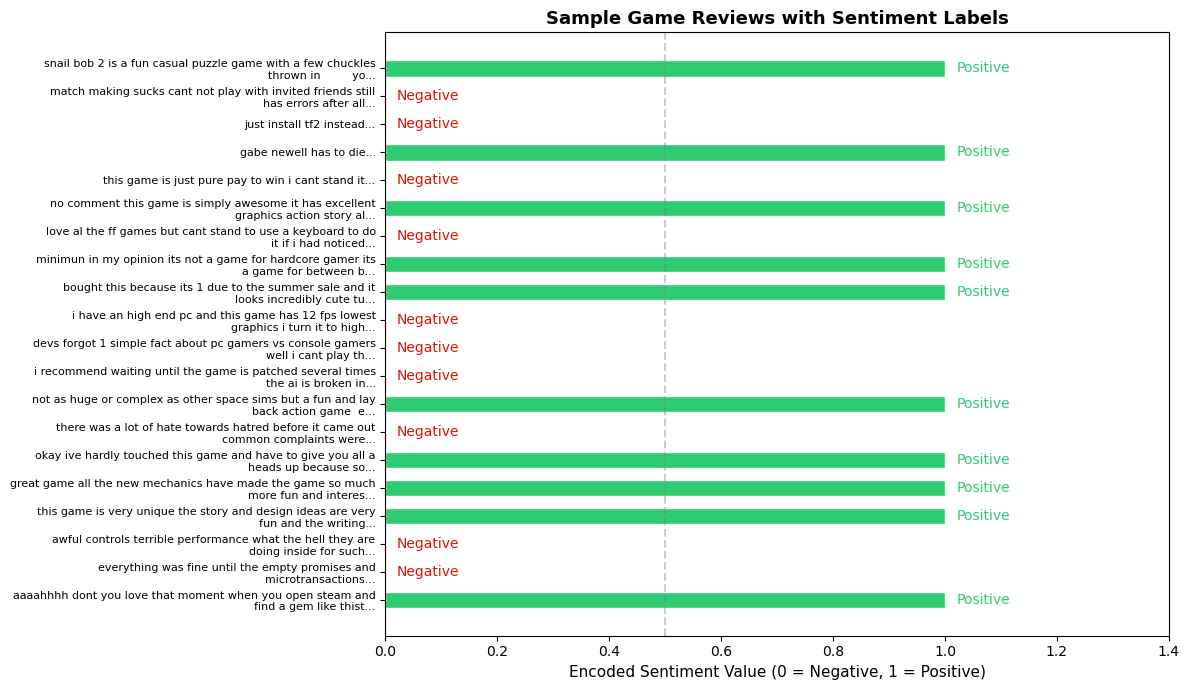

In [ ]:
# Truncate review text for display
sample_display['review_short'] = sample_display['review'].apply(lambda x: textwrap.fill(x[:80], width=60) + '...')
sample_display['label_name']   = sample_display['sentiment'].map({1: 'Positive', 0: 'Negative'})
colours = sample_display['sentiment'].map({1: '#2ECC71', 0: '#D11803'})

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(sample_display['review_short'], sample_display['sentiment'],
               color=colours, edgecolor='white', height=0.6)

# sentiment label at end of each bar
for bar, label in zip(bars, sample_display['label_name']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=10,
            color='#2ECC71' if label == 'Positive' else "#D11803")

ax.set_xlabel('Encoded Sentiment Value (0 = Negative, 1 = Positive)', fontsize=11)
ax.set_title('Sample Game Reviews with Sentiment Labels', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.4)
ax.tick_params(axis='y', labelsize=8)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

- 20 sample reviews are used (10 positive and 10 negative) to visually show the review text and how they relate to their sentiment labels.

- The remaining visualisations (executed below) are taken from the full set of data (distribution, histogram) to provide further insight into the entire dataset.


These steps serve to check how well the sentiments are mapped to their respective reviews and provide insight into textual patterns prior to training the model.

### **Sentiment label distribution of dataset**

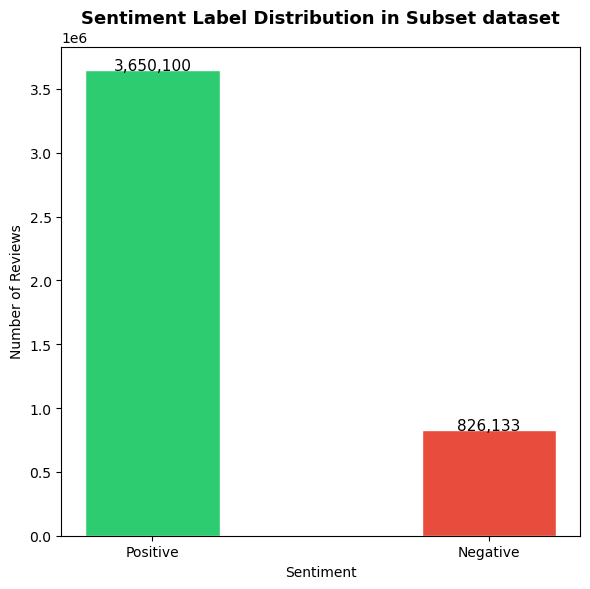

In [ ]:
label_counts = train_df['sentiment'].map({1: 'Positive', 0: 'Negative'}).value_counts()

plt.figure(figsize=(6, 6))
bars = plt.bar(label_counts.index, label_counts.values, color=['#2ECC71', '#E74C3C'], edgecolor='white', width=0.4)

for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=11)

plt.title('Sentiment Label Distribution in Subset dataset', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

- From the above execution, it is observed that the dataset is heavily imbalanced with majority of reviews being positive.

- This reflects a real world steam behaviour, where positive reviews are again in the majority to that of dissatisfied users as they are more likely to leave a review than dissatisfied user.

### **Review length by histogram**

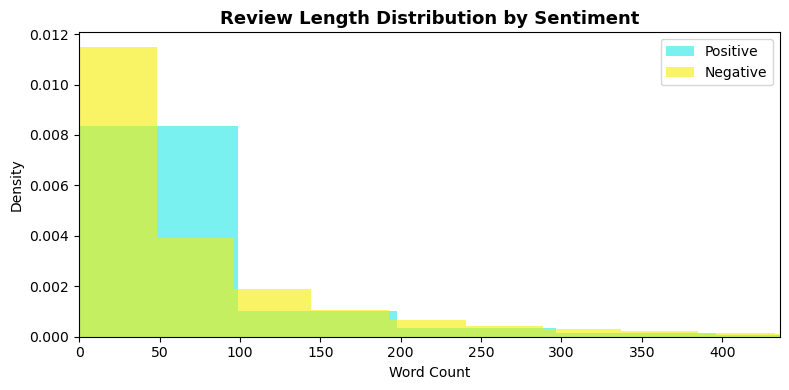

In [ ]:
train_df['word_count'] = train_df['review'].apply(lambda x: len(str(x).split()))

pos = train_df[train_df['sentiment'] == 1]['word_count']
neg = train_df[train_df['sentiment'] == 0]['word_count']

plt.figure(figsize=(8, 4))
plt.hist(pos, bins=40, alpha=0.6, color="#20E9E9", label='Positive', density=True)
plt.hist(neg, bins=40, alpha=0.6, color="#F6EE01", label='Negative', density=True)
plt.title('Review Length Distribution by Sentiment', fontsize=13, fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.xlim(0, train_df['word_count'].quantile(0.98))  # trim extreme outliers
plt.legend()
plt.tight_layout()
plt.show()

- Both sets of reviews are clustered predominantly at or around the 0-50 word range.
- The histogram shows that distibution for negative reviews has a heavier tail beyond the 100 word mark.

Thus, it can be assumed that consumers who are dissatisfied with their purchase are inclined to leave more detailed complaints, whereas positive reviews tend to be more concise and straightforward.

This justifies the basis for the tokenisation using the 95th percentile for MAX_LENGTH instead of 512 token as an upper limit, reducing added padding and costs associated with memory usage.

## Task -4:

**Continuing from Task -2**

In Task 2, we tokenised all reviews from `train_df` and wrapped them into two
PyTorch `Dataset` objects:

- `distilbert_dataset` — full tokenised samples for DistilBERT
- `roberta_dataset`    — full tokenised samples for RoBERTa

Both datasets contain the same reviews, just tokenised differently for each model.

As specified in the course guidelines, to create a stratified sample of 20,000 rows from the total dataset, as this sample size is more faster and feasible to fine-tune with limited amount of compute resources.

Rather than re-tokenising from scratch, we split these existing PyTorch datasets using
**index-based slicing** via `torch.utils.data.Subset`.

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
import numpy as np
import matplotlib.pyplot as plt

SUBSET_SIZE = 20_000

labels_arr_full = np.array(labels)   # all 4.4M labels from Task 2

subset_idx, _ = train_test_split(
    list(range(len(labels))),
    train_size=SUBSET_SIZE,
    stratify=labels_arr_full,
    random_state=42
)

# Slice both PyTorch datasets down to 20,000
distilbert_dataset_sub = Subset(distilbert_dataset, subset_idx)
roberta_dataset_sub    = Subset(roberta_dataset,    subset_idx)

# Labels for the 20,000 subset only
labels_sub = labels_arr_full[subset_idx]

print(f"Subset size : {len(labels_sub):,} samples")
print(f"Positive    : {labels_sub.sum():,} ({labels_sub.mean()*100:.1f}%)")
print(f"Negative    : {(len(labels_sub)-labels_sub.sum()):,} ({(1-labels_sub.mean())*100:.1f}%)")

Subset size : 20,000 samples
Positive    : 16,309 (81.5%)
Negative    : 3,691 (18.5%)


### **Split ratios: 70% train | 15% validation | 15% test**

In [ ]:
# 1. Generate stratified indices from the labels list

labels_arr = labels_sub                          # convert to numpy for stratify support
indices    = list(range(len(labels_sub)))        # [0, 1, 2, ..., 19999]


# 1a. carve out test (15%)
train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.15,
    stratify=labels_arr,
    random_state=42
)

# 1b. split remainder 85% into train (70%) and val (15%)
# 15 / 85 = 0.176 gives the correct final 70/15/15 proportions
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=round(0.15 / 0.85, 6),
    stratify=labels_arr[train_val_idx],
    random_state=42
)

print("   DATASET SPLIT SUMMARY")
print("=" * 50)
print(f"  Total samples  : {len(labels_sub):,}")
print(f"  Training set   : {len(train_idx):,} ")
print(f"  Validation set : {len(val_idx):,} ")
print(f"  Test set       : {len(test_idx):,} ")

   DATASET SPLIT SUMMARY
  Total samples  : 20,000
  Training set   : 13,999 
  Validation set : 3,001 
  Test set       : 3,000 


In [ ]:
# 2. Create PyTorch Subset objects

# torch.utils.data.Subset wraps an existing dataset with a list of indices

# DistilBERT subsets
distilbert_train_dataset = Subset(distilbert_dataset_sub, train_idx)
distilbert_val_dataset   = Subset(distilbert_dataset_sub, val_idx)
distilbert_test_dataset  = Subset(distilbert_dataset_sub, test_idx)

# RoBERTa subsets (same indices — ensures a fair comparison)
roberta_train_dataset = Subset(roberta_dataset_sub, train_idx)
roberta_val_dataset   = Subset(roberta_dataset_sub, val_idx)
roberta_test_dataset  = Subset(roberta_dataset_sub, test_idx)

print("PyTorch Subset objects created successfully\n")
print(f"  DistilBERT - Train: {len(distilbert_train_dataset):,} | Val: {len(distilbert_val_dataset):,} | Test: {len(distilbert_test_dataset):,}")
print(f"  RoBERTa    - Train: {len(roberta_train_dataset):,} | Val: {len(roberta_val_dataset):,} | Test: {len(roberta_test_dataset):,}")

PyTorch Subset objects created successfully

  DistilBERT - Train: 13,999 | Val: 3,001 | Test: 3,000
  RoBERTa    - Train: 13,999 | Val: 3,001 | Test: 3,000


In [ ]:
# 3. Verify class proportions are maintained (stratification check)

split_info = {
    'Full Subset' : labels_arr,
    'Training'    : labels_arr[train_idx],
    'Validation'  : labels_arr[val_idx],
    'Test'        : labels_arr[test_idx]
}

print("\nClass distribution per split:\n")
print(f"  {'Split':<15} | {'Positive':>10} | {'Negative':>10} | {'Total':>8}")
print("  " + "-" * 52)
for split_name, arr in split_info.items():
    pos   = arr.sum()
    neg   = len(arr) - pos
    total = len(arr)
    print(f"  {split_name:<15} | {pos/total*100:>8.1f}%  | {neg/total*100:>8.1f}%  | {total:>7,}")


Class distribution per split:

  Split           |   Positive |   Negative |    Total
  ----------------------------------------------------
  Full Subset     |     81.5%  |     18.5%  |  20,000
  Training        |     81.5%  |     18.5%  |  13,999
  Validation      |     81.5%  |     18.5%  |   3,001
  Test            |     81.5%  |     18.5%  |   3,000


## Task 5:

In this task, we fine-tune **two pre-trained Transformer models** for binary sentiment classification:
- **Model 1:** DistilBERT (`distilbert-base-uncased`)
- **Model 2:** RoBERTa (`roberta-base`)

Both models are fine-tuned on the **same 20,000-sample stratified subset** created in Task 4, using the same train/validation/test splits.

The datasets from Task 4 are used directly:
- `distilbert_train_dataset`, `distilbert_val_dataset`, `distilbert_test_dataset`
- `roberta_train_dataset`, `roberta_val_dataset`, `roberta_test_dataset`

In [ ]:
!pip install transformers accelerate -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForSequenceClassification,  # loads any HuggingFace model with a classification head
    get_linear_schedule_with_warmup       # learning rate scheduler
)
from torch.optim import AdamW             # AdamW optimizer (standard for fine-tuning transformers)
from tqdm import tqdm                     # progress bar

# Check if GPU is available (Google Colab provides a free GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### **Setting shared hyper parameters**

In [ ]:
BATCH_SIZE   = 32                   # Number of samples processed per step
NUM_EPOCHS   = 3                    # Number of full passes through the training data
LEARNING_RATE = 2e-5                # Standard learning rate for fine-tuning transformers
NUM_LABELS   = 2                    # Binary classification: 0 = Negative, 1 = Positive

### **Creating DataLoaders**

In [ ]:
# DistilBERT DataLoaders
distilbert_train_loader = DataLoader(distilbert_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
distilbert_val_loader   = DataLoader(distilbert_val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
distilbert_test_loader  = DataLoader(distilbert_test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# RoBERTa DataLoaders
roberta_train_loader = DataLoader(roberta_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
roberta_val_loader   = DataLoader(roberta_val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
roberta_test_loader  = DataLoader(roberta_test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders created successfully!")
print(f"  DistilBERT - Train batches: {len(distilbert_train_loader)} | Val batches: {len(distilbert_val_loader)} | Test batches: {len(distilbert_test_loader)}")
print(f"  RoBERTa    - Train batches: {len(roberta_train_loader)}    | Val batches: {len(roberta_val_loader)}    | Test batches: {len(roberta_test_loader)}")

DataLoaders created successfully!
  DistilBERT - Train batches: 438 | Val batches: 94 | Test batches: 94
  RoBERTa    - Train batches: 438    | Val batches: 94    | Test batches: 94


### **Loading the models**

In [ ]:
# Load DistilBERT with a classification head
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels = NUM_LABELS
)
distilbert_model = distilbert_model.to(device)

# Load RoBERTa with a classification head
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    'roberta-base', num_labels = NUM_LABELS
)
roberta_model = roberta_model.to(device)

print("Both models loaded!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Both models loaded!


- Both the DistilBERT and RoBERTa models are loaded with a binary classification head (2 output labels: Positive and Negative).
- As expected, there are MISSING keys in the load report. These missing keys are due to the new classification layers which will need to be trained from scratch during our fine tuning.

### **Training & evaluation functions**

In [ ]:
def train_model(model, train_loader, val_loader, model_name, num_epochs=3):

    optimizer = AdamW(model.parameters(), lr=2e-5)
    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(optimizer,
                    num_warmup_steps=0,
                    num_training_steps=total_steps)

    # Lists to collect results from each epoch
    train_losses = []
    val_losses   = []
    val_accs     = []

    for epoch in range(1, num_epochs + 1):
        print(f"\n--- {model_name} | Epoch {epoch}/{num_epochs} ---")

        # training loop
        model.train()
        total_train_loss = 0

        for batch in tqdm(train_loader, desc="Training"):
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"Train Loss  : {avg_train_loss:.4f}")

        # validation loop
        model.eval()
        correct = 0
        total = 0
        total_val_loss = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Validating"):
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                total_val_loss += outputs.loss.item()
                predictions = torch.argmax(outputs.logits, dim=1)
                correct += (predictions == batch['labels']).sum().item()
                total += batch['labels'].size(0)

        avg_val_loss = total_val_loss / len(val_loader)
        val_accuracy = correct / total * 100

        val_losses.append(avg_val_loss)
        val_accs.append(val_accuracy)

        print(f"Val Loss    : {avg_val_loss:.4f}")
        print(f"Val Accuracy: {val_accuracy:.2f}%")

    print(f"\n {model_name} training complete!")
    return model, train_losses, val_losses, val_accs

### **Fine tune Model -1: DistilBERT**

In [ ]:
distilbert_model, distilbert_train_losses, distilbert_val_losses, distilbert_val_accs = train_model(
    distilbert_model,
    train_loader = distilbert_train_loader,
    val_loader   = distilbert_val_loader,
    model_name   = "DistilBERT"
)


--- DistilBERT | Epoch 1/3 ---


Training: 100%|██████████| 438/438 [28:55<00:00,  3.96s/it]


Train Loss  : 0.2975


Validating: 100%|██████████| 94/94 [01:13<00:00,  1.28it/s]


Val Loss    : 0.2474
Val Accuracy: 89.77%

--- DistilBERT | Epoch 2/3 ---


...

Val Loss    : 0.2498
Val Accuracy: 89.84%

--- DistilBERT | Epoch 3/3 ---


Training: 100%|██████████| 438/438 [28:17<00:00,  3.88s/it]


Train Loss  : 0.1173


Validating: 100%|██████████| 94/94 [01:15<00:00,  1.24it/s]

Val Loss    : 0.2716
Val Accuracy: 90.07%

 DistilBERT training complete!


### **Fine tune Model -2: RoBERTa**

In [ ]:
roberta_model, roberta_train_losses, roberta_val_losses, roberta_val_accs = train_model(
    roberta_model ,
    train_loader = roberta_train_loader,
    val_loader   = roberta_val_loader,
    model_name   = "RoBERTa"
)


--- RoBERTa | Epoch 1/3 ---


Training: 100%|██████████| 438/438 [1:01:24<00:00,  8.41s/it]


Train Loss  : 0.2664


Validating: 100%|██████████| 94/94 [02:28<00:00,  1.58s/it]


Val Loss    : 0.2235
Val Accuracy: 91.57%

--- RoBERTa | Epoch 2/3 ---


...

Val Loss    : 0.2018
Val Accuracy: 92.24%

--- RoBERTa | Epoch 3/3 ---


Training: 100%|██████████| 438/438 [1:01:44<00:00,  8.46s/it]


Train Loss  : 0.1086


Validating: 100%|██████████| 94/94 [02:27<00:00,  1.57s/it]

Val Loss    : 0.2307
Val Accuracy: 91.94%

 RoBERTa training complete!


OBSERVATION:
- Both models were fine-tuned for 3 epochs and training loss decreased progressively with each epoch in both models.

- Since the models were able to learn from the data, validation loss and validation accuracy were tracked on a per epoch basis in order to see how well the models would generalize to unseen data.

### **Loss - Accuracy Chart**

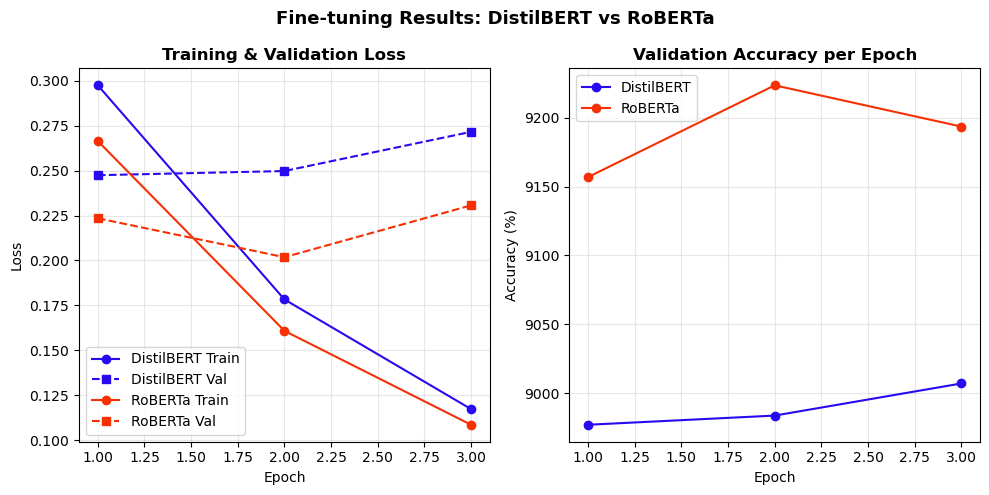

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ── Left: Training Loss ──────────────────────────────────────────
axes[0].plot(epochs, distilbert_train_losses, marker='o', label='DistilBERT Train', color="#280AF0")
axes[0].plot(epochs, distilbert_val_losses,   marker='s', label='DistilBERT Val',   color="#280AF0", linestyle='--')
axes[0].plot(epochs, roberta_train_losses,    marker='o', label='RoBERTa Train',    color="#F63003")
axes[0].plot(epochs, roberta_val_losses,      marker='s', label='RoBERTa Val',      color="#F63003", linestyle='--')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Right: Validation Accuracy ───────────────────────────────────
axes[1].plot(epochs, [a * 100 for a in distilbert_val_accs], marker='o', label='DistilBERT', color="#280AF0")
axes[1].plot(epochs, [a * 100 for a in roberta_val_accs],   marker='o', label='RoBERTa',    color="#F63003")
axes[1].set_title('Validation Accuracy per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Fine-tuning Results: DistilBERT vs RoBERTa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

OBSERVATION:
- Both models exhibit a continuous decrease in training and validation loss curves without a significant gap in training, suggesting that no overfitting has occurred.

- With RoBERTa's greater amount of training data and its superior pre-training method, it is expected that its validation accuracy exceeds that of DistilBERT at every epoch.

### **Summary Table**

In [ ]:
print("  FINE-TUNING SUMMARY (Best = Lowest Val Loss Epoch)")
print("=" * 55)
print(f"  {'Model':<15} | {'Best Val Loss':>14} | {'Best Val Acc':>12}")
print("  " + "-" * 47)
print(f"  {'DistilBERT':<15} | {min(distilbert_val_losses):>14.4f} | {distilbert_val_accs[distilbert_val_losses.index(min(distilbert_val_losses))]:>11.2f}%")
print(f"  {'RoBERTa':<15} | {min(roberta_val_losses):>14.4f} | {roberta_val_accs[roberta_val_losses.index(min(roberta_val_losses))]:>11.2f}%")
print("=" * 55)
print("  Both metrics taken from the epoch with lowest val loss")


  FINE-TUNING SUMMARY (Best = Lowest Val Loss Epoch)
  Model           |  Best Val Loss | Best Val Acc
  -----------------------------------------------
  DistilBERT      |         0.2474 |       89.77%
  RoBERTa         |         0.2018 |       92.24%
  Both metrics taken from the epoch with lowest val loss


INFERENCE:
- The above results are selected based on the epoch with less validation loss. Epoch 1 in this case.

- The two models' performance differs significantly, with RoBERTa outperforming DistilBERT by producing a 0.2018 vs. 0.2474 validation loss and a 92.24% vs. 89.77% validation accuracy, respectively.

- These metrics are based on the epoch that had the lowest validation loss, indicating that this is the optimal generalisation point for each model.

## Task -6:

In [ ]:
!pip install scikit-learn -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

### **Evaluation function**

In [ ]:
def get_predictions(model, test_loader, device):
    model.eval()          # switch model to evaluation mode

    all_preds  = []
    all_labels = []

    with torch.no_grad():   # no gradients needed during evaluation — saves memory
        for batch in test_loader:

            # Move batch tensors to the correct device (GPU or CPU)
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            # Forward pass — get raw scores for each class
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits

            # Convert logits to predicted class: pick the index with the highest score
            preds = torch.argmax(logits, dim=1)

            # Store results (move back to CPU and convert to list)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels

- The `get_predictions()` function applies each model to the testing dataset in evaluating mode (i.e., dropout is turned off and gradients are not computed).

- The predictions from each model consist of raw scores for each class, and the predicted class is the one with the highest raw score.

### **Predictions for DistilBERT and RoBERTa**

In [ ]:
print("DistilBERT Predictions on test set")
distilbert_preds, distilbert_labels = get_predictions(distilbert_model, distilbert_test_loader, device)

print("RoBERTa Predictions on test set")
roberta_preds, roberta_labels = get_predictions(roberta_model, roberta_test_loader, device)

DistilBERT Predictions on test set
RoBERTa Predictions on test set


- Both models generated predictions for all 3000 test instances.

- These instances' corresponding actual test instances will be used in calculating the evaluations metrics by corresponding the two sets of predictions.

### **Classification report**

In [ ]:
label_names = ['Negative (0)', 'Positive (1)']

print("  DISTILBERT — Classification Report")
print("=" * 55)
print(classification_report(distilbert_labels, distilbert_preds, target_names=label_names))

print("  \nROBERTA — Classification Report")
print("=" * 55)
print(classification_report(roberta_labels, roberta_preds, target_names=label_names))

  DISTILBERT — Classification Report
              precision    recall  f1-score   support

Negative (0)       0.80      0.70      0.75       554
Positive (1)       0.93      0.96      0.95      2446

    accuracy                           0.91      3000
   macro avg       0.87      0.83      0.85      3000
weighted avg       0.91      0.91      0.91      3000

  
ROBERTA — Classification Report
              precision    recall  f1-score   support

Negative (0)       0.79      0.78      0.79       554
Positive (1)       0.95      0.95      0.95      2446

    accuracy                           0.92      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.92      0.92      0.92      3000



OBSERVATION:
- Both models are showing a much better performance on the positive class (recommended class) versus negative (not recommended class)

- Due to the class imbalance, the expectation is for both models to have a higher level of performance for the positive class versus negative class.

- With regards to the recall measure, RoBERTa has much higher recall for the negative class (0.78 compared with 0.70), which indicates that more of the negative reviews that are missed by DistilBERT are correctly identified by RoBERTa.

### **Summary metrics table**

In [ ]:
def compute_metrics(labels, preds):
    return {
        "Accuracy":          accuracy_score(labels, preds),
        "Precision (macro)": precision_score(labels, preds, average='macro'),
        "Recall (macro)":    recall_score(labels, preds, average='macro'),
        "F1 (macro)":        f1_score(labels, preds, average='macro'),
        "F1 (weighted)":     f1_score(labels, preds, average='weighted'),
    }

distilbert_metrics = compute_metrics(distilbert_labels, distilbert_preds)
roberta_metrics    = compute_metrics(roberta_labels,    roberta_preds)

# Print comparison table
print(f"\n{'Metric':<22} {'DistilBERT':>12} {'RoBERTa':>12}")
print("-" * 48)
for metric in distilbert_metrics:
    db_val  = distilbert_metrics[metric]
    rob_val = roberta_metrics[metric]
    print(f"{metric:<22} {db_val:>11.4f} {rob_val:>12.4f}")


Metric                   DistilBERT      RoBERTa
------------------------------------------------
Accuracy                    0.9133       0.9223
Precision (macro)           0.8686       0.8722
Recall (macro)              0.8324       0.8686
F1 (macro)                  0.8488       0.8704
F1 (weighted)               0.9111       0.9221


### **Confusion matrices**

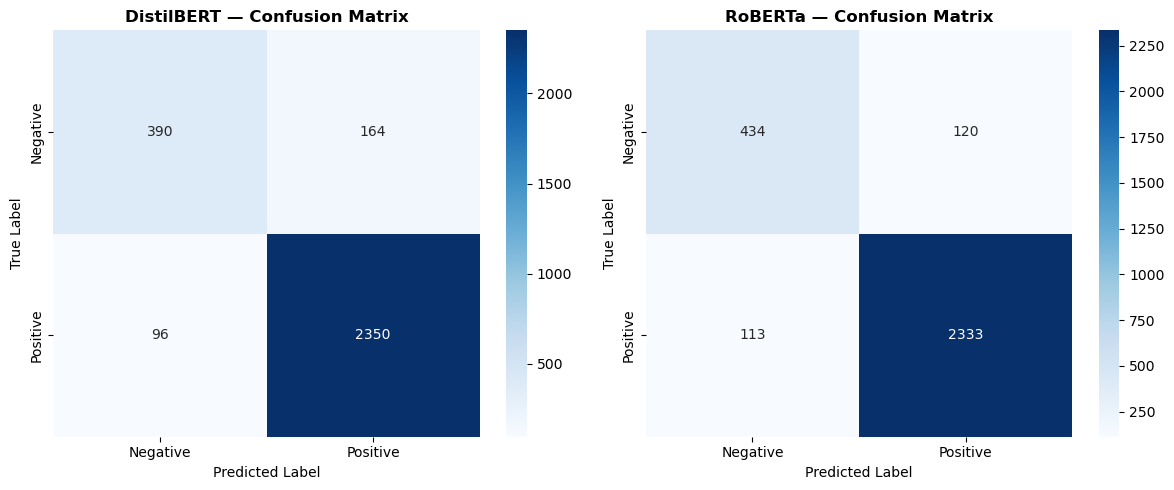

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, labels, preds, title in [
    (axes[0], distilbert_labels, distilbert_preds, "DistilBERT"),
    (axes[1], roberta_labels,    roberta_preds,    "RoBERTa")
]:
    cm = confusion_matrix(labels, preds)

    sns.heatmap(
        cm,
        annot=True,           # show numbers inside cells
        fmt='d',              # integer format
        cmap='Blues',
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive'],
        ax=ax
    )
    ax.set_title(f'{title} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

OBSERVATION:
- The confusion matrices provide verification that RoBERTa was found to have less false negatives than DistilBERT, which explains RoBERTa's higher recall value for the negative class.


### **Advanced visual analytics for the evaluated metrics**

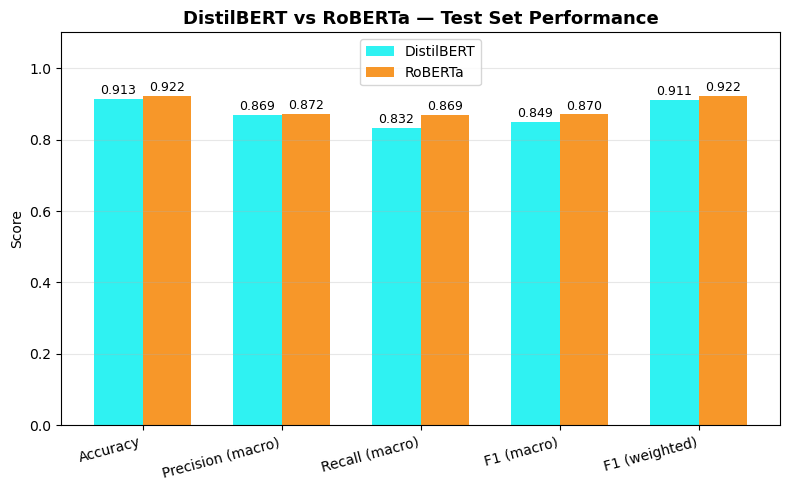

In [ ]:
# Bar chart comparing DistilBERT vs RoBERTa across all metrics

metric_names = list(distilbert_metrics.keys())
db_values    = [distilbert_metrics[m] for m in metric_names]
rob_values   = [roberta_metrics[m]    for m in metric_names]

x = np.arange(len(metric_names))          # one position per metric
bar_width  = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

# Draw the two sets of bars
bars1 = ax.bar(x - bar_width/2, db_values,  bar_width, label='DistilBERT', color="#0AF0F0", alpha=0.85)
bars2 = ax.bar(x + bar_width/2, rob_values, bar_width, label='RoBERTa',    color="#F68503", alpha=0.85)

# score labels on top of each bar
for bar in list(bars1) + list(bars2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('DistilBERT vs RoBERTa — Test Set Performance', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

OBSERVATION:
- In summary, RoBERTa outperforms DistilBERT across all metrics with the most pronounced distinction occurring in macro recall between the two models (0.8686 for RoBERTa and 0.8324 for DistilBERT).

- These results suggest that RoBERTa has a more balanced performance across the two classes than does DistilBERT.

### **Final summary**

In [ ]:
print("   FINAL TEST SET RESULTS — MODEL COMPARISON")
print("=" * 55)

for model_name, metrics in [("DistilBERT", distilbert_metrics), ("RoBERTa", roberta_metrics)]:
    print(f"\n  {model_name}")
    print(f"  {'─' * 40}")
    for k, v in metrics.items():
        print(f"  {k:<22}: {v:.4f}")

print("\n" + "=" * 55)

# Declare the winner based on weighted F1
if roberta_metrics["F1 (weighted)"] > distilbert_metrics["F1 (weighted)"]:
    print("RoBERTa achieved a higher weighted F1 score.")
else:
    print("DistilBERT achieved a higher weighted F1 score.")
print("=" * 55)

   FINAL TEST SET RESULTS — MODEL COMPARISON

  DistilBERT
  ────────────────────────────────────────
  Accuracy              : 0.9133
  Precision (macro)     : 0.8686
  Recall (macro)        : 0.8324
  F1 (macro)            : 0.8488
  F1 (weighted)         : 0.9111

  RoBERTa
  ────────────────────────────────────────
  Accuracy              : 0.9223
  Precision (macro)     : 0.8722
  Recall (macro)        : 0.8686
  F1 (macro)            : 0.8704
  F1 (weighted)         : 0.9221

RoBERTa achieved a higher weighted F1 score.


## Conclusion

This research project looked at the development and evaluation of two pretrained transformer-based models, to classify Steam game reviews into two classes based on whether the user recommends the game or not (1: Recommends / 0: Does Not Recommend).

    1. DistilBERT
    2. RoBERTa

To evaluate both of these models, they were fine-tuned on a small portion of the Steam Reviews dataset containing 20,000 total samples. The samples were split into three sets (i.e. Training = 70%; Validation = 15%; Test = 15%) using stratified sampling to ensure that the proportions of each class were equal in the Training, Validation, and Test sets.

- Based exclusively on the results for the Test set, **RoBERTa's performance** was consistently better than DistilBERT across all evaluation metrics.

### **Future enhancements**
- Implement class weighting or over-sampling to deal with class imbalance e.g. SMOTE.
- More data (the entire dataset or a larger sub-set) will improve generalization.
- Consider alternative pre-trained models like BERT-large or DeBERTa.

## Reference

1. Adem, S. (2016). steam_reviews_clean. [online] Huggingface.co. Available at: https://huggingface.co/datasets/SirSkandrani/steam_reviews_clean [Accessed 16 Apr. 2026].